# Workshop in CS240
Exploratory Data Analysis(EDA) 0n netflix Dataset

Problem Farming เพื่อวิเคราะห์ประเภทของหนังและซีรีส์ที่ได้รับความนิยมบน Netflix

In [93]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import missingno
import warnings
warnings.filterwarnings('ignore')

# Data Acquisition

In [2]:
# Mount to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Read data
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Fetch the dimensions of data
df.shape

(8807, 12)

**Data Description**

*   show_id – Unique ID of each show (no duplicates).
*   type – Content type: Movie or TV Show
*   title – Title of the movie/TV show (unique).
*   director – Director(s) (≈30% missing values).
*   cast – Main cast (≈9% missing).
*   country – Country of production
*   date_added – Date added to Netflix
*   release_year – Original release year.
*   rating – Audience rating
*   duration – Length of content:
*   listed_in – Categories/genres (e.g., Dramas, International Movies).
*   description – Short description of the title.













In [6]:
# Drop column
netflix_cleaned = df.iloc[:,1:]

In [7]:
netflix_cleaned.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Checking and handling duplicate data

In [8]:
netflix_cleaned.duplicated().sum()

np.int64(0)

In [55]:
n_dupliccate = 5
duplicate_rows = netflix_cleaned.sample(n=n_dupliccate, replace=True, random_state=1)
netflix_cleaned = pd.concat([netflix_cleaned, duplicate_rows], ignore_index=True)

In [56]:
# To check the number of duplicate values
netflix_cleaned.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
8807,True
8808,True
8809,True
8810,True


In [57]:
netflix_cleaned.duplicated().sum()

np.int64(5)

In [58]:
netflix_cleaned[netflix_cleaned.duplicated()]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8807,Movie,Untold: Caitlyn Jenner,Crystal Moselle,NaN,NaN,"August 24, 2021",2021,TV-PG,70 min,"Documentaries, LGBTQ Movies, Sports Movies",Caitlyn Jenner's unlikely path to Olympic glor...
8808,TV Show,The Golden Path,NaN,"Li Nanxing, Chen Liping, Chew Chor Meng, Tay P...",NaN,"November 1, 2017",2007,TV-MA,1 Season,"International TV Shows, TV Dramas",A single mother of five struggles for decades ...
8809,Movie,Super Me,Zhang Chong,"Darren Wang, Song Jia, Cao Bingkun, Wu Gang, C...",China,"May 8, 2021",2021,TV-14,104 min,"Action & Adventure, Dramas, International Movies",A struggling screenwriter discovers his lucrat...
8810,TV Show,Queens vs. Kings,NaN,"Varun Thakur, Anu Menon, Rahul Subramanian, Si...",NaN,"October 25, 2018",2018,TV-14,1 Season,"Stand-Up Comedy & Talk Shows, TV Comedies","No ""ism"" is left unturned in this celebrity ga..."
8811,Movie,System Crasher,Nora Fingscheidt,"Helena Zengel, Albrecht Schuch, Gabriela Maria...",Germany,"February 21, 2020",2020,TV-MA,120 min,"Dramas, Independent Movies, International Movies","Traumatized, violent and yearning for love, 9-..."


In [59]:
# Drop duplicated values
netflix_dropdup = netflix_cleaned.drop_duplicates()

In [60]:
netflix_dropdup

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...
8802,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


# Checking and handling inconsistent Datatypes

In [61]:
# Find unique values in column 'type'
netflix_dropdup['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [64]:
# Find unique values in each categorical column
for col in netflix_dropdup.select_dtypes(include=['object']).columns:
  print(f'{col}: {netflix_dropdup[col].unique()}')

type: ['Movie' 'TV Show']
title: ['Dick Johnson Is Dead' 'Blood & Water' 'Ganglands' ... 'Zombieland'
 'Zoom' 'Zubaan']
director: ['Kirsten Johnson' nan 'Julien Leclercq' ... 'Majid Al Ansari'
 'Peter Hewitt' 'Mozez Singh']
cast: [nan
 'Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng'
 'Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera'
 ...
 'Jesse Eisenberg, Woody Harrelson, Emma Stone, Abigail Breslin, Amber Heard, Bill Murray, Derek Graf'
 'Tim Allen, Courteney Cox, Chevy Chase, Kate Mara, Ryan Newman, Michael Cassidy, Spencer Breslin, Rip Torn, Kevin Zegers'
 'Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanana, Manish Chaudhary, Meghna 

In [68]:
#แก้ไขcountry
import numpy as np
df['country'] = (
    df['country']
    .astype(str)  # Convert to string
    .str.strip()  # Trim spaces at the beginning and end
    .str.strip(',')  # Trim commas at the front and back
    .replace('nan', np.nan)  # Change 'nan' back to NaN
)

In [69]:
df['country'] = df['country'].str.replace(r'\s*,\s*', ', ', regex=True)

In [70]:
#แก้ไขduration
def parse_duration(x):
    if pd.isna(x):
        return np.nan, np.nan
    if 'Season' in x:
        return int(x.split()[0]), 'Season'
    elif 'min' in x:
        return int(x.split()[0]), 'Minutes'
    else:
        return np.nan, np.nan

df['duration_value'], df['duration_type'] = zip(*df['duration'].map(parse_duration))

In [71]:
# แก้ rating ที่เป็นตัวเลขหรือ min โดยเอาออก
valid_ratings = ['G','PG','PG-13','R','NC-17','TV-Y','TV-Y7','TV-G','TV-PG','TV-14','TV-MA','UR','NR','TV-Y7-FV']
df['rating'] = df['rating'].apply(lambda x: x if x in valid_ratings else np.nan)

In [72]:
# แปลง date_added เป็น datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [73]:
# Find unique values in each categorical column
for col in netflix_dropdup.select_dtypes(include=['object']).columns:
  print(f'{col}: {netflix_dropdup[col].unique()}')

type: ['Movie' 'TV Show']
title: ['Dick Johnson Is Dead' 'Blood & Water' 'Ganglands' ... 'Zombieland'
 'Zoom' 'Zubaan']
director: ['Kirsten Johnson' nan 'Julien Leclercq' ... 'Majid Al Ansari'
 'Peter Hewitt' 'Mozez Singh']
cast: [nan
 'Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwanya, Mekaila Mathys, Sandi Schultz, Duane Williams, Shamilla Miller, Patrick Mofokeng'
 'Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noureddine Farihi, Geert Van Rampelberg, Bakary Diombera'
 ...
 'Jesse Eisenberg, Woody Harrelson, Emma Stone, Abigail Breslin, Amber Heard, Bill Murray, Derek Graf'
 'Tim Allen, Courteney Cox, Chevy Chase, Kate Mara, Ryan Newman, Michael Cassidy, Spencer Breslin, Rip Torn, Kevin Zegers'
 'Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanana, Manish Chaudhary, Meghna 

There is no inconsistent values.

# Checking and handling missing data

In [74]:
netflix_dropdup.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8807 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8807 non-null   object
 1   title         8807 non-null   object
 2   director      6173 non-null   object
 3   cast          7982 non-null   object
 4   country       7976 non-null   object
 5   date_added    8797 non-null   object
 6   release_year  8807 non-null   int64 
 7   rating        8803 non-null   object
 8   duration      8804 non-null   object
 9   listed_in     8807 non-null   object
 10  description   8807 non-null   object
dtypes: int64(1), object(10)
memory usage: 825.7+ KB


In [75]:
# Check for missing values
netflix_dropdup.isnull()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,True,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,False
3,False,False,True,True,True,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
8802,False,False,False,False,False,False,False,False,False,False,False
8803,False,False,True,True,True,False,False,False,False,False,False
8804,False,False,False,False,False,False,False,False,False,False,False
8805,False,False,False,False,False,False,False,False,False,False,False


In [76]:
# Check number of missing values
netflix_dropdup.isnull().sum()

,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3
listed_in,0


In [83]:
# Remove rows with missing values
netflix_dropmissing_director = netflix_dropdup.dropna(subset=['director','cast','country','rating','duration'])

In [84]:
# Check number of missing values
netflix_dropmissing_director.isnull().sum()

,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


There is no missing data.

# EDA and Data Visualization

In [86]:
# Get summary statistics of numerical variables
print(netflix_dropmissing_director.describe())

       release_year
count   5332.000000
mean    2012.742123
std        9.625831
min     1942.000000
25%     2011.000000
50%     2016.000000
75%     2018.000000
max     2021.000000


*   ข้อมูลท้งหมดมี 5332 แถวtem
*   ข้อมูลครอบคลุมตั้งแต่ปี 1942 ถึง 2021

*   ปีที่เผยแพร่โดยเฉลี่ยคือ ประมาณปี 2012
*   ข้อมลส่วนใหญ่อยู่ระหว่าง 2011 ถึง2018



<Axes: xlabel='type', ylabel='count'>

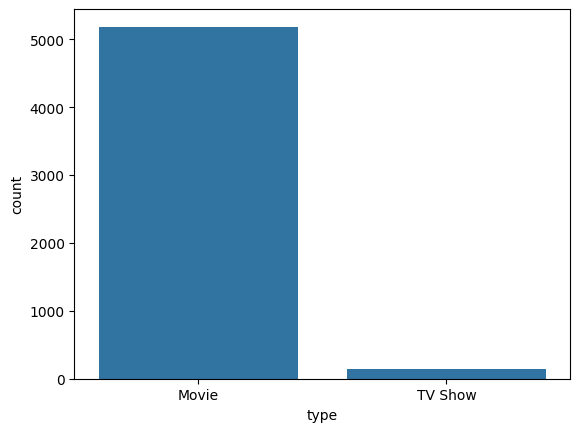

In [87]:
# Plot frequency for column 'type' using seaborn package
sb.countplot(x='type', data=netflix_dropmissing_director)

จากกราฟข้างต้น เราสามารถสรุปได้ว่ารายการส่วนใหญ่ที่เพิ่มเข้ามาใน Netflix คือ Movie

In [103]:
# Analyze the distribution of 'type' by 'rating'
type_rating_counts = netflix_dropmissing_director.groupby(['type', 'rating']).size().unstack(fill_value=0)

display(type_rating_counts)

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
type,,,,,,,,,,,,,,
Movie,40,2,58,275,470,778,1177,81,1741,416,71,70,3,3
TV Show,0,0,0,0,0,0,37,3,81,15,5,6,0,0


In [105]:
# Calculate percentage distribution of ratings for each type
type_rating_percentage = type_rating_counts.apply(lambda x: x / x.sum(), axis=1)

display(type_rating_percentage)

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
type,,,,,,,,,,,,,,
Movie,0.007715,0.000386,0.011186,0.053038,0.090646,0.150048,0.227001,0.015622,0.335776,0.080231,0.013693,0.013500,0.000579,0.000579
TV Show,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.251701,0.020408,0.551020,0.102041,0.034014,0.040816,0.000000,0.000000


หนังมักจะมีเรตติ้งผู้ใหญ่มากกว่า (R, PG-13, TV-MA)

ซีรีส์ทีวีมีเรตติ้งสำหรับเด็กหรือผู้ชมทั่วไปมากกว่า (TV-G, TV-PG)

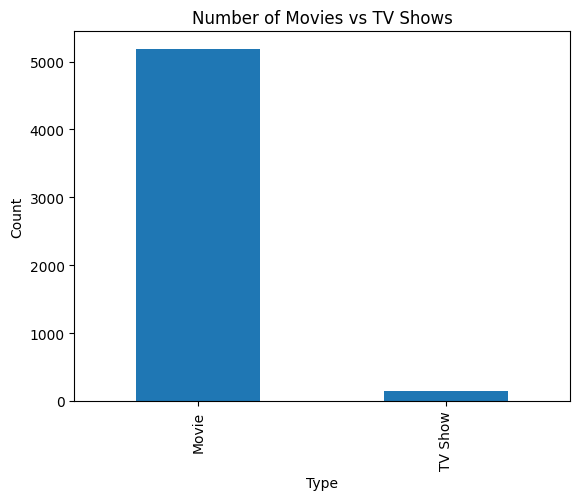

In [110]:
# Histogram: to display the distribution of passenger ages.
netflix_dropmissing_director['type'].value_counts().plot(kind='bar')
plt.xlabel('Type')
plt.ylabel('Count')
plt.title('Number of Movies vs TV Shows')
plt.show()

เนื้อหาส่วนใหญ่ในNetflixเป็นหนัง และมีซีรีส์เล็กน้อย

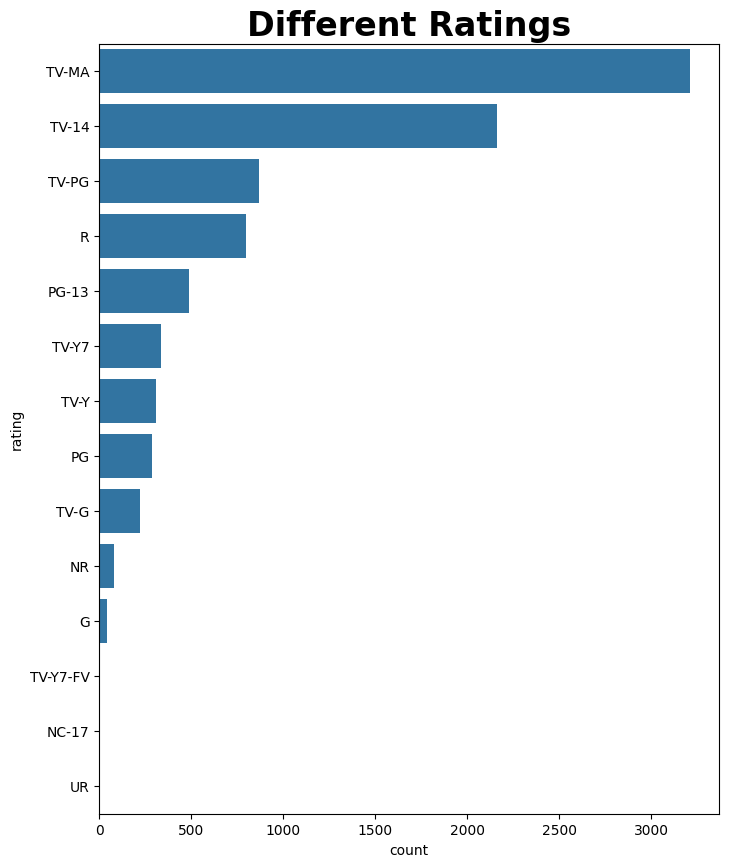

In [115]:
# Count plot for different ratings
plt.figure(figsize=(8, 10))
sns.countplot(y='rating', data=df, order=df.rating.value_counts().index.to_list())
plt.title('Different Ratings', fontsize=24, fontweight='bold');

ดังนั้น TV-MA เป็นเรตติ้งที่พบบ่อยที่สุดบน Netflix